# Tarea 3: dos trampas asociativas en un solo DAG futbolístico

Consigna: preparar un ejemplo, para contar en el pizarrón, de cada uno de los siguientes problemas, explicitando **las ecuaciones del proceso empleado para generar datos**, **mostrando los datos generados** bajo el modelo propuesto y una **historia relacionada**:

1. **Selection bias**: asociación entre variables independientes por condicionar en un colisionador.
2. **Asociación por un ancestro común**: asociación espuria por la presencia de un ancestro común (DAG tenedor).

Un único DAG de 5 variables sobre el fútbol sirve para ilustrar ambos problemas a la vez.

## La historia: el fútbol y su contexto

Tomamos una base de datos de jugadores de cuatro ligas de distinto nivel futbolístico: la Primera B Nacional, la Primera División, la Ligue 1 y la Premier League. De cada jugador conocemos su liga, la cantidad de kinesiólogos del equipo, sus goles, su edad y su valor de mercado (Transfermarkt).

Queremos responder dos preguntas donde la intuición naive falla:

- **Fork**: ¿los jugadores de equipos con **más kinesiólogos** meten más goles por estar mejor físicamente? La tentación es concluir que contratar kinesiólogos *mejora el físico* y eso *causa goles*. En realidad la liga explica ambos: a mayor nivel futbolístico, los clubes contratan más cuerpo médico y, además, es una liga donde se marcan más goles de por sí.
- **Colisionador**: entre los jugadores de **alto valor de mercado**, ¿los que hacen más goles son más jóvenes? Aunque en el DAG `goles` y `edad` son independientes, condicionar en `valor_market` crea una asociación espuria.

### Variables

| Variable | Definición | Valores |
|----------|-----------|---------|
| `liga` | Liga en la que participa el jugador | categórica ordenada: B Nacional $<$ Primera $<$ Ligue 1 $<$ Premier League |
| `kinesiologos` | Kinesiólogos del cuerpo médico del equipo | entero, $\ge 0$ |
| `goles` | Goles del jugador en la temporada | entero, $\ge 0$ |
| `edad` | Edad en años | $[17, 35]$ |
| `valor_market` | Valor de mercado en millones de euros | $\ge 0$ M€ |

### El DAG

El diagrama causal se genera con Mermaid en la celda de código siguiente (vía la API mermaid.ink, por lo que requiere conexión a internet).



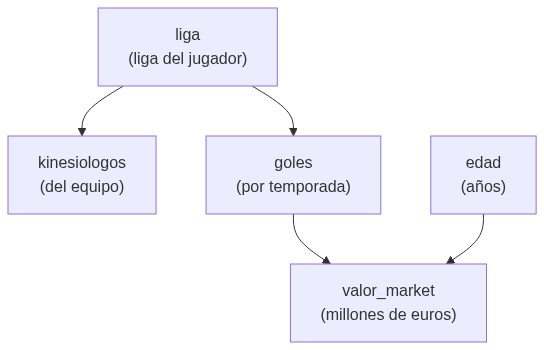

In [1]:
from mermaid import Mermaid
from IPython.display import Image, display

dag = Mermaid("""
flowchart TD
    L["liga<br/>(liga del jugador)"] --> B["kinesiologos<br/>(del equipo)"]
    L --> G["goles<br/>(por temporada)"]
    G --> V["valor_market<br/>(millones de euros)"]
    E["edad<br/>(años)"] --> V
""")

display(Image(data=dag.img_response.content, width=700))


## Proceso de generación de datos

A cada liga le asignamos un **nivel futbolístico** $w$ (a mayor nivel, más goles y más cuerpo médico):

| Liga | $w$ | Probabilidad |
|------|-----|--------------|
| B Nacional | $0$ | 0.15 |
| Primera | $1$ | 0.30 |
| Ligue 1 | $2$ | 0.25 |
| Premier League | $3$ | 0.30 |

Para cada jugador $i$ ($N = 500$), con errores gaussianos independientes entre sí:

$$ w_i \sim \text{Categórica}(0.15,\; 0.30,\; 0.25,\; 0.30) $$

$$ \text{kinesiologos}_i = \max\!\big(0, \; \operatorname{round}(5 + 4\, w_i + \varepsilon_i^{b})\big), \qquad \varepsilon_i^{b} \sim \mathcal{N}(0, \; 0.8^2) $$

$$ \text{goles}_i = \max\!\big(0, \; \operatorname{round}(3 + 4\, w_i + \varepsilon_i^{c})\big), \qquad \varepsilon_i^{c} \sim \mathcal{N}(0, \; 2.2^2) $$

$$ \text{edad}_i \sim \mathcal{N}(24, \; 3^2), \quad \text{truncada a } [17, 35] $$

$$ u_i = 28 - \text{edad}_i \qquad (\text{potencial: la juventud cotiza en el mercado}) $$

$$ \text{valor\_market}_i = \max\!\big(0.2, \; 1 + 1.2\, \text{goles}_i + 2.5\, u_i + \varepsilon_i^{d}\big), \qquad \varepsilon_i^{d} \sim \mathcal{N}(0, \; 3^2) $$

Los coeficientes están calibrados para dos objetivos:

- El nivel de la liga desplaza la media de kinesiólogos y de goles en la misma dirección → la asociación marginal `kinesiologos–goles` es fuerte (fork espurio) y desaparece dentro de cada liga. `kinesiologos` y `goles` son enteros y se recortan solo en su límite inferior para no producir valores imposibles (negativos).
- El valor de mercado responde tanto a los goles como al potencial de edad → `valor_market` es un colisionador de `goles` y `edad`. El potencial $u = 28 - \text{edad}$ codifica que, a igualdad de goles, el mercado paga más por un jugador de 19 que por uno de 34.

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Simulación de los datos

In [3]:
rng = np.random.default_rng(2026)
n_players = 500

league_names = ["B Nacional", "Primera", "Ligue 1", "Premier League"]
league_level = np.array([0, 1, 2, 3])
weights = np.array([0.15, 0.30, 0.25, 0.30])
league_idx = rng.choice(len(league_names), size=n_players, p=weights)
nivel = league_level[league_idx]

kinesiologos = np.maximum(
    0, np.round(5 + 4 * nivel + rng.normal(0, 0.8, n_players))
).astype(int)
goles = np.maximum(
    0, np.round(3 + 4 * nivel + rng.normal(0, 2.2, n_players))
).astype(int)
edad = np.clip(rng.normal(24, 3, n_players), 17, 35)
potencial = 28 - edad
valor_market = np.maximum(
    1 + 1.2 * goles + 2.5 * potencial + rng.normal(0, 3, n_players),
    0.2,
)

data = pd.DataFrame({
    "liga": pd.Categorical(
        [league_names[i] for i in league_idx],
        categories=league_names,
        ordered=True,
    ),
    "nivel": nivel,
    "kinesiologos": kinesiologos,
    "goles": goles,
    "edad": edad,
    "potencial": potencial,
    "valor_market": valor_market,
})

data.head()


,liga,nivel,kinesiologos,goles,edad,potencial,valor_market
0,Primera,1,8,7,22.266259,5.733741,24.965115
1,Ligue 1,2,13,7,24.684118,3.315882,18.949474
2,Ligue 1,2,13,10,26.122811,1.877189,12.755559
3,Primera,1,10,7,27.525695,0.474305,9.510626
4,Primera,1,8,3,23.013544,4.986456,13.347981


In [4]:
data[["kinesiologos", "goles", "edad", "valor_market"]].describe().round(2)


,kinesiologos,goles,edad,valor_market
count,500.00,500.00,500.00,500.00
mean,11.79,9.54,23.77,22.99
std,4.20,4.64,2.92,10.14
min,3.00,0.00,17.00,0.20
25%,9.00,6.00,21.62,15.61
50%,12.00,10.00,23.74,23.39
75%,16.00,13.00,25.84,29.91
max,20.00,22.00,33.19,50.18


In [5]:
data["liga"].value_counts()


liga
Primera           155
Premier League    143
Ligue 1           132
B Nacional         70
Name: count, dtype: int64

## Escenario 1: selection bias por condicionar en un colisionador

Pregunta naive: *¿entre los jugadores de alto valor de mercado, los que más goles hacen son más jóvenes?*

En el DAG, `valor_market` es un **colisionador**: recibe flechas de `goles` y de `edad`. Goles y edad son variables independientes (no hay flecha entre ellas ni ancestro común), por lo que **marginalmente no deben correlacionar**. Sin embargo, al condicionar sobre el colisionador se abre un camino espurio entre sus causas: restringirse a los jugadores caros obliga a que quien llega con poco debe compensar con mucho, y viceversa.

Comparamos la asociación `goles–edad` en toda la muestra contra la sub-muestra de alto valor de mercado (percentil 75).

In [6]:
threshold = np.quantile(data["valor_market"], 0.75)
high_value = data[data["valor_market"] > threshold]
print(f"Umbral de alto valor (P75): {threshold:.1f} M€ -> {len(high_value)} jugadores")

corr_all = np.corrcoef(data["goles"], data["edad"])[0, 1]
corr_high = np.corrcoef(high_value["goles"], high_value["edad"])[0, 1]

slope_all, intercept_all = np.polyfit(data["edad"], data["goles"], deg=1)
slope_high, intercept_high = np.polyfit(high_value["edad"], high_value["goles"], deg=1)

collider_table = pd.DataFrame({
    "Muestra": ["Todos los jugadores", "Alto valor de mercado"],
    "n": [len(data), len(high_value)],
    "corr(goles, edad)": [corr_all, corr_high],
    "Pendiente goles ~ edad": [slope_all, slope_high],
})
collider_table.round(3)


Umbral de alto valor (P75): 29.9 M€ -> 125 jugadores


,Muestra,n,"corr(goles, edad)",Pendiente goles ~ edad
0,Todos los jugadores,500,-0.075,-0.119
1,Alto valor de mercado,125,0.320,0.552


En terminos del potencial (juventud), la correlacion condicional es -0.32: entre los caros, los que menos goles hacen son los mas jovenes y compensan su valor con potencial.


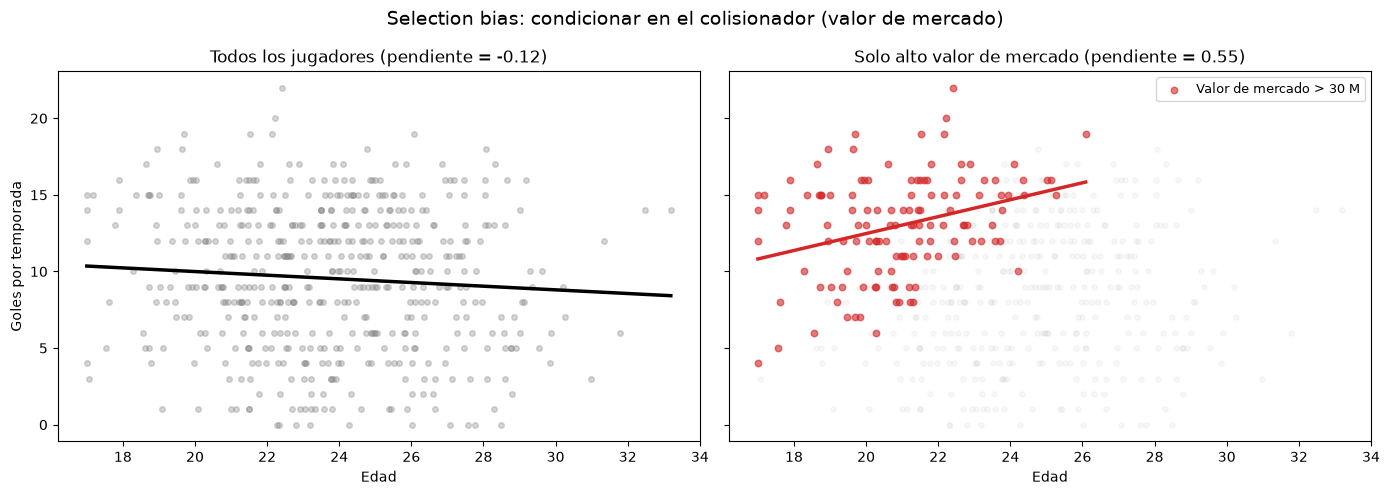

In [7]:
print(
    "En terminos del potencial (juventud), la correlacion condicional es "
    f"{np.corrcoef(high_value['goles'], high_value['potencial'])[0, 1]:.2f}: "
    "entre los caros, los que menos goles hacen son los mas jovenes y "
    "compensan su valor con potencial."
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True, sharex=True)

axes[0].scatter(data["edad"], data["goles"], alpha=0.35, s=16, color="#888888")
x_all = np.linspace(data["edad"].min(), data["edad"].max(), 100)
axes[0].plot(x_all, slope_all * x_all + intercept_all, color="black", lw=2.5)
axes[0].set_title(f"Todos los jugadores (pendiente = {slope_all:.2f})")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Goles por temporada")

axes[1].scatter(data["edad"], data["goles"], alpha=0.15, s=14, color="#cccccc")
axes[1].scatter(
    high_value["edad"], high_value["goles"],
    alpha=0.6, s=22, color="#d62728",
    label=f"Valor de mercado > {threshold:.0f} M",
)
x_high = np.linspace(high_value["edad"].min(), high_value["edad"].max(), 100)
axes[1].plot(x_high, slope_high * x_high + intercept_high, color="#d62728", lw=2.5)
axes[1].set_title(f"Solo alto valor de mercado (pendiente = {slope_high:.2f})")
axes[1].set_xlabel("Edad")
axes[1].legend(fontsize=9)

fig.suptitle("Selection bias: condicionar en el colisionador (valor de mercado)", fontsize=14)
fig.tight_layout()
plt.show()


## Escenario 2: asociación por la presencia de un ancestro común (fork)

Pregunta naive: *¿los jugadores de equipos con más kinesiólogos meten más goles porque están mejor físicamente?* Y de ahí concluir que contratar más kinesiólogos causa más goles.

En el DAG, `liga` es un **ancestro común** de `kinesiologos` y `goles`: las ligas de mayor nivel tienen clubes con más cuerpo médico y, en paralelo, sus partidos tienen más goles de por sí. Sin ajustar por liga, `kinesiologos` y `goles` aparecen asociados aunque el cuerpo médico no produzca goles.

Comparamos la correlación agregada y la pendiente de `goles ~ kinesiologos` en la muestra completa contra las pendientes **dentro de cada liga**. Si la asociación es espuria, la correlación debería colapsar de ≈0.9 a ≈0 al controlar por liga y las pendientes dentro de cada liga deberían ser planas.

In [8]:
corr_pooled = np.corrcoef(data["kinesiologos"], data["goles"])[0, 1]
slope_pooled, intercept_pooled = np.polyfit(data["kinesiologos"], data["goles"], deg=1)

rows = []
for league_name in league_names:
    frame = data[data["liga"] == league_name]
    slope = np.polyfit(frame["kinesiologos"], frame["goles"], deg=1)[0]
    corr = np.corrcoef(frame["kinesiologos"], frame["goles"])[0, 1]
    rows.append({
        "Liga": league_name,
        "n": len(frame),
        "Pendiente goles ~ kinesiologos": slope,
        "corr(kinesiologos, goles)": corr,
    })
fork_table = pd.DataFrame(rows)

X = np.column_stack([
    np.ones(len(data)),
    (data["nivel"] == 1).to_numpy().astype(float),
    (data["nivel"] == 2).to_numpy().astype(float),
    (data["nivel"] == 3).to_numpy().astype(float),
])
res_kine = data["kinesiologos"] - X @ np.linalg.lstsq(X, data["kinesiologos"], rcond=None)[0]
res_gol = data["goles"] - X @ np.linalg.lstsq(X, data["goles"], rcond=None)[0]
partial_corr = np.corrcoef(res_kine, res_gol)[0, 1]

print(f"Correlacion agregada kinesiologos-goles: {corr_pooled:.2f}")
print(f"Correlacion parcial kinesiologos-goles | liga (residualizacion): {partial_corr:.2f}")
print(f"Pendiente agregada goles ~ kinesiologos: {slope_pooled:.3f}")
fork_table.round(3)


Correlacion agregada kinesiologos-goles: 0.87
Correlacion parcial kinesiologos-goles | liga (residualizacion): 0.07
Pendiente agregada goles ~ kinesiologos: 0.960


,Liga,n,Pendiente goles ~ kinesiologos,"corr(kinesiologos, goles)"
0,B Nacional,70,0.475,0.215
1,Primera,155,0.197,0.073
2,Ligue 1,132,0.363,0.143
3,Premier League,143,-0.136,-0.058


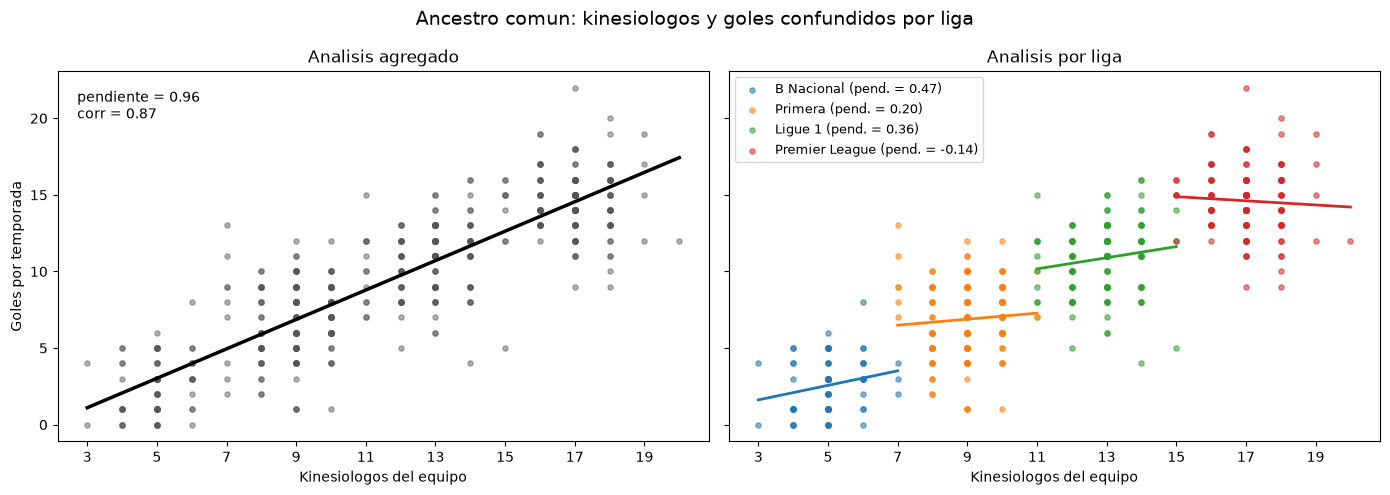

In [9]:
league_colors = {
    "B Nacional": "#1f77b4",
    "Primera": "#ff7f0e",
    "Ligue 1": "#2ca02c",
    "Premier League": "#d62728",
}

x = data["kinesiologos"].to_numpy()
x_ticks = range(int(x.min()), int(x.max()) + 1, 2) if int(x.max()) - int(x.min()) >= 4 else range(int(x.min()), int(x.max()) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True, sharex=True)

axes[0].scatter(x, data["goles"], alpha=0.45, s=14, color="#555555")
x_all = np.linspace(x.min(), x.max(), 100)
axes[0].plot(x_all, slope_pooled * x_all + intercept_pooled, color="black", lw=2.5)
axes[0].set_title("Analisis agregado")
axes[0].set_xlabel("Kinesiologos del equipo")
axes[0].set_ylabel("Goles por temporada")
axes[0].set_xticks(list(x_ticks))
axes[0].text(
    0.03, 0.95,
    f"pendiente = {slope_pooled:.2f}\ncorr = {corr_pooled:.2f}",
    transform=axes[0].transAxes, va="top", fontsize=10,
)

for league_name in league_names:
    mask = data["liga"] == league_name
    frame = data[mask]
    slope, intercept = np.polyfit(frame["kinesiologos"], frame["goles"], deg=1)
    xs = np.linspace(frame["kinesiologos"].min(), frame["kinesiologos"].max(), 100)
    axes[1].scatter(
        frame["kinesiologos"], frame["goles"],
        alpha=0.55, s=14, color=league_colors[league_name],
        label=f"{league_name} (pend. = {slope:.2f})",
    )
    axes[1].plot(xs, slope * xs + intercept, color=league_colors[league_name], lw=2)

axes[1].set_title("Analisis por liga")
axes[1].set_xlabel("Kinesiologos del equipo")
axes[1].set_xticks(list(x_ticks))
axes[1].legend(fontsize=9)

fig.suptitle("Ancestro comun: kinesiologos y goles confundidos por liga", fontsize=14)
fig.tight_layout()
plt.show()


## Conclusión

Ambas trampas son caras de la misma moneda: **correlación no es causación**.

- **Colisionador (`valor_market`)** → NO condicionar. El valor de mercado es un resultado conjunto de `goles` y `edad`. Al restringir el análisis a los jugadores caros se induce una correlación espuria entre sus causas. Regla: no condicionar sobre una variable que es *causada* por dos variables independientes (ni sobre sus descendientes).
- **Ancestro común (`liga`)** → SÍ ajustar. La asociación marginal `kinesiologos–goles` colapsa de ≈0.9 a ≈0 al controlar por liga, tanto dentro de cada liga como por residualización. Regla: condicionar sobre los antecesores comunes que confunden la relación de interés. En este caso el confounder es una variable categórica de sólo 4 valores, lo que permite ver el colapso de la asociación con simpleza.

El mismo conjunto de datos muestra una asociación espuria y otra supuestamente "real" según qué se condicione: la lista de controles no es un detalle técnico, sino la decisión causal clave.
